In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.stats.api as sms
import scipy.stats as stats
from statsmodels.graphics.tsaplots import plot_acf
from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt
import seaborn as sns

from previoABC import flujo_previo_ABC
from funciones import comprobar_dimensiones_ubic
from funciones2 import *

In [2]:
data_ABC = flujo_previo_ABC(region = "Los Santos", print_comprobacion_dimensiones = True)

True


In [3]:
# Calibración de modelos mediante Approximate Bayesian Computation (ABC)
dt_errores = pd.read_parquet('20260613_santos.parquet')

In [4]:
datos_santos_train = data_ABC["train"]
datos_santos_train_pivot = data_ABC["train_pivot"]
datos_santos_test = data_ABC["test"]
nsites_santos = data_ABC["nsites"]
nsites_training_santos = data_ABC["nsites_training"]
OLS_santos = data_ABC["OLS"]
ubic_santos = data_ABC["ubic"]
ubic_training_santos = data_ABC["ubic_training"]
dist_mat_santos = data_ABC["dist_mat"]
dist_mat_training_santos = data_ABC["dist_mat_training"]
m_training_santos = data_ABC["m_training"]

<Axes: >

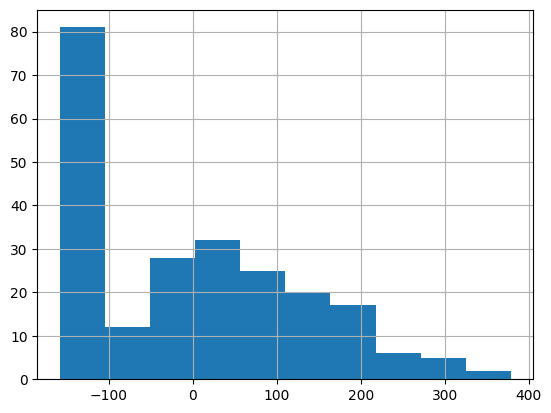

In [19]:
(datos_santos_train[(datos_santos_train['lon']==-84.1) &(datos_santos_train['lat']==9.9)].chirps - 158.45732675078162).hist()

In [13]:
# Fecha corte para training
fecha_corte_2018 = pd.to_datetime('2018-12-31')

# Identificar Y_pred
# Aplica constante (promedio sobre exp(errores)) para volver a la escala original
datos_santos_train["Y_pred"] = np.mean(np.exp(datos_santos_train["logY_residuos"])) * np.exp(datos_santos_train["logY_pred"]) - 1
datos_santos_test["Y_pred"] = np.mean(np.exp(datos_santos_test["logY_residuos"])) * np.exp(datos_santos_test["logY_pred"]) - 1

In [14]:
# Modificaciones para generar simulaciones en testing
datos_santos_test2 = datos_santos_test[datos_santos_test['date'] > fecha_corte_2018]
datos_santos_test2_pivot = datos_santos_test2.pivot(index='date', columns=['lat','lon'], values='exp_residuos')
m_testing_santos = int(len(datos_santos_test2)/nsites_santos)

In [15]:
comprobar_dimensiones_ubic(ubic_santos, datos_santos_test2_pivot)

True

In [ ]:
def estadisticos_reg_lineal(train, reg_lineal):
    print(reg_lineal.summary2())

    logY_residuos = train["logY_residuos"]

    # Heterocedasticidad (Breusch-Pagan)
    bp_test = sms.het_breuschpagan(logY_residuos, reg_lineal.model.exog)
    print(f"Breusch-Pagan test p-value: {bp_test[1]:.4f}")

def plot_modelo_regresion_lineal_global(datos):
    a = datos
    a_real = a["chirps"]
    a_log_Y = a["logY"]

    a_pred = a["Y_pred"]
    a_logY_pred = a["logY_pred"]
    
    a_logY_residuos = a["logY_residuos"]

    plt.figure()
    plt.scatter(a_real, a_pred)
    plt.plot([a_real.min(), a_real.max()],[a_real.min(), a_real.max()], linestyle='--')
    plt.xlabel("Y chirps")
    plt.ylabel("Y pred")
    plt.title("Y chirps vs Y pred")
    plt.show()

    plt.figure()
    plt.scatter(a_log_Y, a_logY_pred)
    plt.plot([a_log_Y.min(), a_log_Y.max()],[a_log_Y.min(), a_log_Y.max()], linestyle='--')
    plt.xlabel("Log Y chirps")
    plt.ylabel("Log Y pred")
    plt.title("Log Y chirps vs Log Y pred")
    plt.show()

    plt.figure()
    plt.scatter(a_logY_pred, a_logY_residuos)
    plt.axhline(0, linestyle='--')
    plt.xlabel("Log Y pred")
    plt.ylabel("Residuos")
    plt.title("Residuos vs Log Y pred")
    plt.show()

    plt.figure()
    sns.histplot(a_logY_residuos, kde=True)
    plt.title("Histograma de residuos")
    plt.ylabel("Conteos")
    plt.show()

    plt.figure()
    stats.probplot(a_logY_residuos, dist="norm", plot=plt)
    plt.title("QQ-plot Log Y residuos")
    plt.show()

    plt.figure()
    plt.scatter(a_logY_pred, np.sqrt(np.abs(a_logY_residuos)))
    plt.xlabel("Log Y pred")
    plt.ylabel("|Log Y residuos|^(1/2)")
    plt.title("Scale-Location")
    plt.show()
    
    plt.figure()
    plot_acf(a_logY_residuos, lags=30)
    plt.title("ACF Log Y residuos")
    plt.show()

In [ ]:
# OLS
estadisticos_reg_lineal(datos_santos_train, OLS_santos)

In [ ]:
# Training
plot_modelo_regresion_lineal_global(datos_santos_train)

In [ ]:
# Testing
plot_modelo_regresion_lineal_global(datos_santos_test)

In [ ]:
def plot_modelo_regresion_lineal_ubic(datos, ubic, max_plots=10):
    count = 0

    for _, row in ubic.iterrows():
        lat, lon = row['lat'], row['lon']
        
        a = datos[(datos['lat'] == lat) & (datos['lon'] == lon)].copy()

        # Crear figura con 3 subplots
        fig, axes = plt.subplots(3, 1, figsize=(10, 8))

        # 1. Serie temporal
        axes[0].plot(a["date"], a["chirps"], label="chirps")
        axes[0].plot(a["date"], a["Y_pred"], label="Y_pred")
        axes[0].set_title(f"Lat={lat}, Lon={lon}")
        axes[0].set_ylabel("Precipitaciones")
        axes[0].legend()
        axes[0].grid()

        # 2. Residuos en log
        axes[1].plot(a["date"], a["logY_residuos"], label="LogY residuos")
        axes[1].axhline(0, linestyle='--')
        axes[1].set_ylabel("LogY residuos")
        axes[1].set_xlabel("Fecha")
        axes[1].grid()

        # 3. QQ-plot residuos
        stats.probplot(a["logY_residuos"], dist="norm", plot=axes[2])
        axes[2].set_title("QQ-plot LogY residuos")

        plt.tight_layout()
        plt.show()
    
        count += 1
        if count >= max_plots:
            break

In [ ]:
# Training
plot_modelo_regresion_lineal_ubic(datos_santos_train, ubic_training_santos, 5)

In [ ]:
# Testing
plot_modelo_regresion_lineal_ubic(datos_santos_test, ubic_santos, 10) # nsites_santos)

In [ ]:
# Definir mejor D y M
D_corrida, M_corrida = seleccionar_mejor_modelo(dt_errores, sort_by = 'mean_errorSWD', posicion_n_ranking = 0)
D_corrida, M_corrida = 'D5', 'M1'
print(D_corrida, M_corrida)

In [ ]:
resumen_errores(dt_errores, sort_by = 'mean_errorSWD')

In [ ]:
def plot_simulaciones_exp_errores_vs_real(datos_pivot, m, nsites, dist_mat, D_elegido = D_corrida, M_elegido = M_corrida):
    exp_simulacion_errores = corrida_simulacion_exp_errores(m, nsites, dist_mat, D_elegido, M_elegido, dt_errores, p = 0.01, id_simulacion = None, datos_pivot = datos_pivot)
    serie_simulaciones_promedio = exp_simulacion_errores.mean(axis=1)
    serie_original_exp_errores = datos_pivot.values.mean(axis=1)

    plt.plot(serie_simulaciones_promedio, label = "Simulaciones (sobre exp_errores)", color = "orange")
    plt.plot(serie_original_exp_errores, label = "Datos originales", color = "steelblue")
    plt.xlabel("Mes")
    plt.ylabel("")
    plt.title("Serie temporal de exp(errores)")
    plt.grid()
    plt.legend()
    plt.show()

In [ ]:
# Training
plot_simulaciones_exp_errores_vs_real(datos_santos_train_pivot, m_training_santos, nsites_training_santos, dist_mat_training_santos)

In [ ]:
# Testing
plot_simulaciones_exp_errores_vs_real(datos_santos_test2_pivot, m_testing_santos, nsites_santos, dist_mat_santos)

In [ ]:
def plot_simulaciones_vs_real(datos_prepivot, m, nsites, dist_mat, D_elegido = D_corrida, M_elegido = M_corrida):
    simulaciones = corrida_simulacion_precipitaciones(m, nsites, dist_mat, D_elegido, M_elegido, dt_errores, p = 0.01, id_simulacion = None, datos_prepivot = datos_prepivot)
    simulaciones_promedio = simulaciones.mean(axis=1)
    chirps_promedio = datos_prepivot.pivot(index='date', columns=['lat','lon'], values='chirps').values.mean(axis=1)

    print_metricas_error_presimulaciones(datos_prepivot)
    print_metricas_error_simulaciones(simulaciones, datos_prepivot)

    plt.plot(simulaciones_promedio, label = "Simulaciones", color = "orange")
    plt.plot(chirps_promedio, label = "Datos originales", color = "steelblue")
    plt.xlabel("Mes")
    plt.ylabel("mm")
    plt.title("Precipitaciones mensuales promedio")
    plt.grid()
    plt.legend()
    plt.show()

In [ ]:
# Training
plot_simulaciones_vs_real(datos_santos_train, m_training_santos, nsites_training_santos, dist_mat_training_santos)

In [ ]:
# Testing
plot_simulaciones_vs_real(datos_santos_test2, m_testing_santos, nsites_santos, dist_mat_santos)

In [ ]:
def plot_qqplot_modelo_precipitaciones(datos_prepivot, m, nsites, dist_mat, D_elegido = D_corrida, M_elegido = M_corrida):
    simulaciones = corrida_simulacion_precipitaciones(m, nsites, dist_mat, D_elegido, M_elegido, dt_errores, p = 0.01, id_simulacion = None, datos_prepivot = datos_prepivot)
    datos_pivot = datos_prepivot.pivot(index='date', columns=['lat','lon'], values='logY_pred')
    simulaciones_coords = asignar_coords_a_simulacion(simulaciones, datos_pivot)
    
    # Extraer vectores
    obs = datos_prepivot["chirps"].values
    sim = simulaciones_coords["simulaciones"].values

    # QQ
    q = np.linspace(0.01, 0.99, 100)
    obs_q = np.quantile(obs, q)
    sim_q = np.quantile(sim, q)

    # Plot
    plt.figure(figsize=(6,6))
    plt.scatter(obs_q, sim_q)

    # Identidad
    min_val = min(obs_q.min(), sim_q.min())
    max_val = max(obs_q.max(), sim_q.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--')

    plt.xlabel("Cuantiles observados")
    plt.ylabel("Cuantiles simulados")
    plt.title("QQ-plot global")
    plt.grid()
    plt.show()

In [ ]:
# Training
plot_qqplot_modelo_precipitaciones(datos_santos_train, m_training_santos, nsites_training_santos, dist_mat_training_santos, D_corrida, M_corrida)

In [ ]:
# Testing
plot_qqplot_modelo_precipitaciones(datos_santos_test2, m_testing_santos, nsites_santos, dist_mat_santos, D_corrida, M_corrida)

In [ ]:
def plot_modelo_precipitaciones_ubic(datos_prepivot, ubic, m, nsites, dist_mat, D_elegido = D_corrida, M_elegido = M_corrida, max_plots=15):
    simulaciones = corrida_simulacion_precipitaciones(m, nsites, dist_mat, D_elegido, M_elegido, dt_errores, p = 0.01, id_simulacion = None, datos_prepivot = datos_prepivot)
    datos_pivot = datos_prepivot.pivot(index='date', columns=['lat','lon'], values='logY_pred')
    simulaciones_coords = asignar_coords_a_simulacion(simulaciones,datos_pivot)

    count = 0
    for _, row in ubic.iterrows():
        lat, lon = row['lat'], row['lon']

        a = datos_prepivot[(datos_prepivot['lat'] == lat) & (datos_prepivot['lon'] == lon)].copy()
        b = simulaciones_coords[(simulaciones_coords['lat'] == lat) & (simulaciones_coords['lon'] == lon)].copy()
        df_plot = a.merge(b, on=['date', 'lat', 'lon'])
        df_plot = df_plot.sort_values("date")

        # Crear figura
        fig, axes = plt.subplots(2, 1, figsize=(10, 8))

        # 1. Serie temporal
        axes[0].plot(df_plot["date"], df_plot["chirps"], label="Observado")
        axes[0].plot(df_plot["date"], df_plot["simulaciones"], label="Simulaciones")
        axes[0].set_title(f"Lat={lat}, Lon={lon}")
        axes[0].set_ylabel("Precipitaciones")
        axes[0].legend()
        axes[0].grid()

        # 2. QQ-plot
        q = np.linspace(0.01, 0.99, 50)

        obs_q = np.quantile(df_plot["chirps"], q)
        sim_q = np.quantile(df_plot["simulaciones"], q)

        axes[1].scatter(obs_q, sim_q)

        min_val = min(obs_q.min(), sim_q.min())
        max_val = max(obs_q.max(), sim_q.max())

        axes[1].plot([min_val, max_val], [min_val, max_val], 'r--')

        axes[1].set_title("QQ-plot (cuantiles)")
        axes[1].set_xlabel("Observado")
        axes[1].set_ylabel("Simulaciones")
        axes[1].grid()

        plt.tight_layout()
        plt.show()

        count += 1
        if count >= max_plots:
            break

In [ ]:
# Training
plot_modelo_precipitaciones_ubic(datos_santos_train, ubic_training_santos, m_training_santos, nsites_training_santos, dist_mat_training_santos, D_corrida, M_corrida, max_plots = 5)

In [ ]:
# Testing
plot_modelo_precipitaciones_ubic(datos_santos_test2, ubic_santos, m_testing_santos, nsites_santos, dist_mat_santos, D_corrida, M_corrida, max_plots = 5)

In [ ]:
listado_percentiles(dt_errores)

In [ ]:
# Percentil 1% sobre TODAS las variantes de modelos
resumen_errores(filtrar_df_por_percentil(dt_errores, 'errorSWD', p = 0.01), sort_by = 'mean_errorMSE')

In [ ]:
# Percentil 1% asignado entre cada subgrupo de combinaciones de modelos
top1p = filtrar_df_errores_por_percentil_agrupado(dt_errores, "errorMSE", p = 0.01)

top1p.groupby(['modelo', 'covariables'], as_index=False).agg(
    mean_errorSWD=('errorSWD', 'mean'),
    sd_errorSWD = ('errorSWD', 'std'),
    mean_errorMSE = ('errorMSE', 'mean'),
    sd_errorMSE = ('errorMSE', 'std'),
    n = ('errorSWD', 'count')
).sort_values('mean_errorMSE', ascending=True)

In [ ]:
top1p.groupby(['modelo', 'covariables'], as_index=False).agg(
    mean_errorSWD=('errorSWD', 'mean'),
    sd_errorSWD = ('errorSWD', 'std'),
    mean_errorMSE = ('errorMSE', 'mean'),
    sd_errorMSE = ('errorMSE', 'std'),
    n = ('errorSWD', 'count')
).sort_values('mean_errorMSE', ascending=True)

In [ ]:
def histograma_parametros_modelo(dt_parametros, D_elegido, M_elegido, error_columna="errorSWD", p=0.01):
    previas_calibradas = ['delta', 'phi', 'sigma', 'beta3', 'rho']
    topXp = filtrar_df_errores_por_percentil_agrupado(dt_parametros, error_columna, p=p)
    df_modelo = topXp.loc[(topXp["modelo"] == D_elegido) & (topXp["covariables"] == M_elegido)]

    n = len(previas_calibradas)
    ncols = 3
    nrows = int(np.ceil(n / ncols))

    fig, axs = plt.subplots(nrows, ncols, figsize=(12, 4*nrows))
    axs = axs.flatten()

    for i, col in enumerate(previas_calibradas):
        ax = axs[i]
        if col in df_modelo.columns:
            ax.hist(df_modelo[col].dropna(), bins=20, color='tab:blue', edgecolor='black')
            ax.set_title(col, fontsize=10)
            ax.tick_params(labelsize=8)
        else:
            ax.set_visible(False)

    for j in range(i+1, len(axs)):
        axs[j].set_visible(False)

    plt.suptitle("Histogramas de parámetros", fontsize=14)
    plt.tight_layout()
    plt.show()

In [ ]:
# ABC
histograma_parametros_modelo(dt_errores, D_corrida, M_corrida, error_columna = "errorMSE", p = 0.01)

In [ ]:
# ABC
histograma_parametros_modelo(dt_errores, "D3", "M1", error_columna = "errorMSE", p = 0.01)

In [ ]:
resumen_test = comparar_test_DyM(
    datos_santos_test2,
    m_testing_santos,
    nsites_santos,
    dist_mat_santos,
    dt_errores,
    n_simulaciones=1000,
    p=0.01
)

In [ ]:
resumen_test#.to_clipboard(index=False)

In [ ]:
simulaciones_test = corrida_n_simulaciones_precipitaciones(m_testing_santos, nsites_santos, dist_mat_santos, 'D3', 'M1', dt_errores, n_simulaciones=1000, datos_prepivot=datos_santos_test2)

In [10]:
def plot_qq_bandas_ubicaciones(
    simulaciones,
    datos_prepivot,
    ubic,
    ubic_training=None,
    max_plots=None,
    q=np.linspace(0.01, 0.99, 50),
    ncols=5,
    figsize_por_plot=(3, 3.2)
):
    chirps_pivot = datos_prepivot.pivot(
        index="date",
        columns=["lat", "lon"],
        values="chirps"
    )

    columnas = chirps_pivot.columns
    chirps = chirps_pivot.values

    if max_plots is None:
        max_plots = ubic.shape[0]

    ubic = ubic.head(max_plots).reset_index(drop=True)

    if ubic_training is not None:
        coords_training = set(
            zip(
                ubic_training["lat"],
                ubic_training["lon"]
            )
        )
    else:
        coords_training = set()

    nplots = ubic.shape[0]
    nrows = int(np.ceil(nplots / ncols))

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(figsize_por_plot[0] * ncols, figsize_por_plot[1] * nrows)
    )

    axes = np.array(axes).reshape(-1)

    for i, row in ubic.iterrows():
        lat, lon = row["lat"], row["lon"]

        if (lat, lon) not in columnas:
            axes[i].axis("off")
            continue

        j = columnas.get_loc((lat, lon))

        obs_q = np.quantile(chirps[:, j], q)

        sim_q = np.quantile(simulaciones[:, :, j], q, axis=1).T
        sim_q_med = np.median(sim_q, axis=0)
        sim_q_low = np.quantile(sim_q, 0.025, axis=0)
        sim_q_high = np.quantile(sim_q, 0.975, axis=0)

        min_val = min(obs_q.min(), sim_q_low.min())
        max_val = max(obs_q.max(), sim_q_high.max())

        if ubic_training is not None and (lat, lon) not in coords_training:
            etiqueta = "★ TEST"
        else:
            etiqueta = "TRAIN"

        axes[i].fill_between(obs_q, sim_q_low, sim_q_high, alpha=0.25)
        axes[i].plot(obs_q, sim_q_med, linestyle="--")
        axes[i].scatter(obs_q, sim_q_med, s=12)
        axes[i].plot([min_val, max_val], [min_val, max_val], linestyle=":")

        axes[i].set_title(f"{etiqueta} | lon: {lon}, lat: {lat}", fontsize=10)
        axes[i].set_xlabel("Real")
        axes[i].set_ylabel("Simulado")
        axes[i].grid(True)

    for j in range(nplots, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

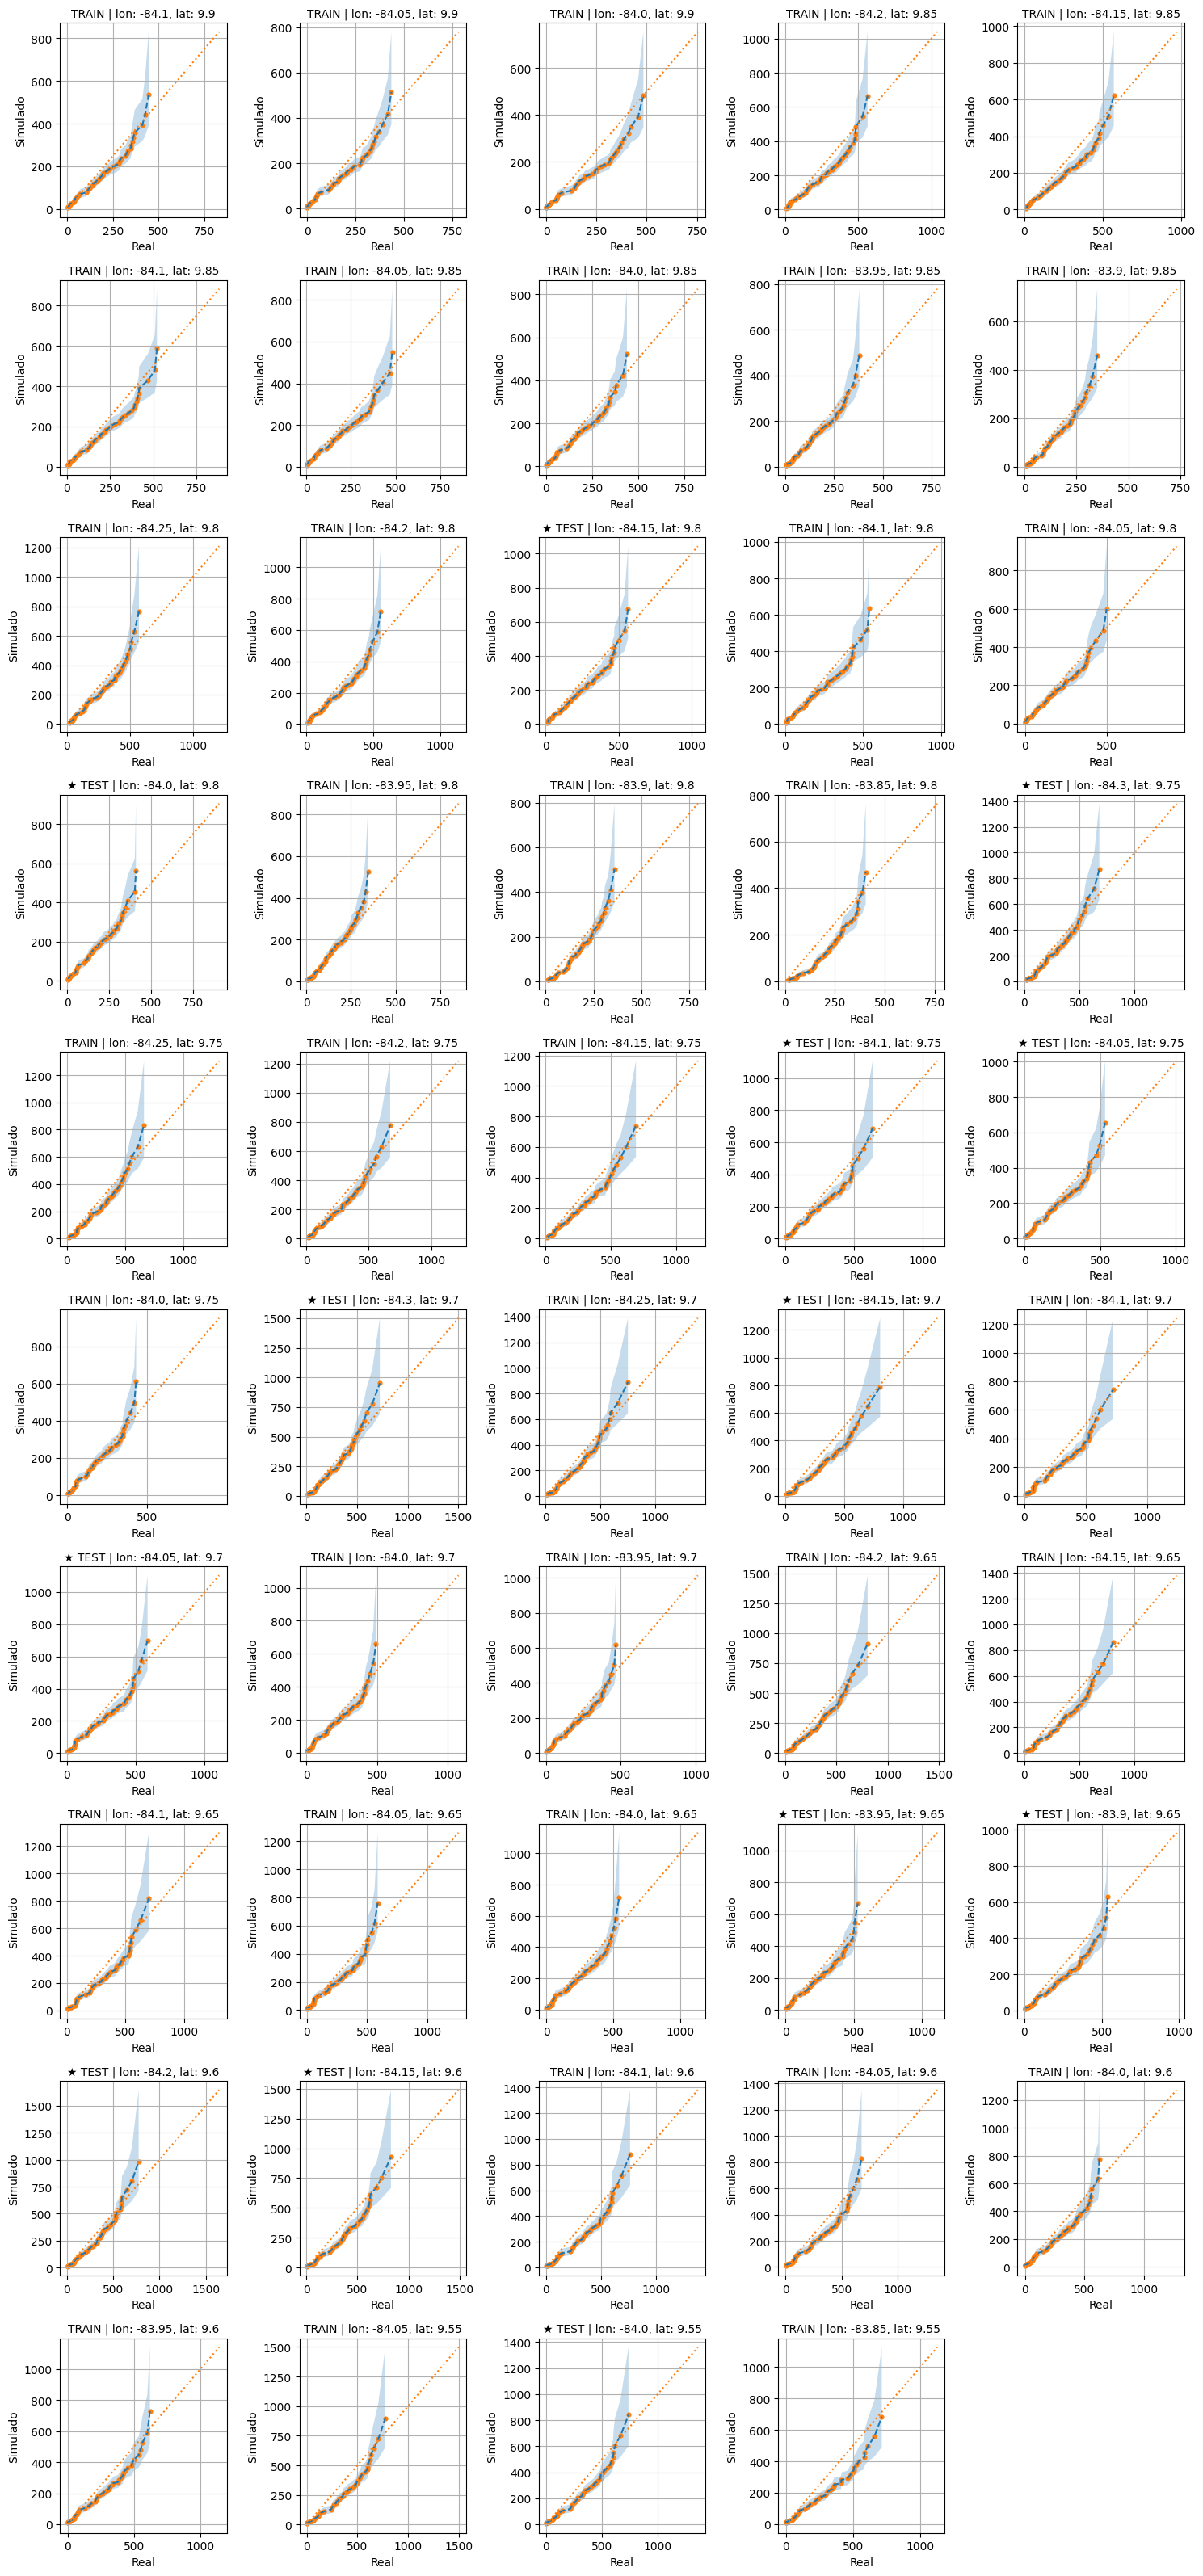

In [16]:
plot_qq_bandas_ubicaciones(simulaciones_test, datos_santos_test2, ubic=ubic_santos, ubic_training=ubic_training_santos)

In [ ]:
from joblib import dump

dump(
    {
        "simulaciones_test": simulaciones_test,
        "resumen_test": resumen_test,
    },
    "workspace.joblib"
)

In [1]:
from joblib import load

workspace = load("workspace.joblib")

simulaciones_test = workspace["simulaciones_test"]
resumen_test = workspace["resumen_test"]